<a href="https://colab.research.google.com/github/siimka113/Computer-Vision-Project/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Object Detection Using YOLO <b> </h1></center>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

This tutorial is designed to provide a comprehensive understanding of how to use YOLO, a state-of-the-art method in computer vision, for detecting objects in images.

Object detection and classification is a key technology in many areas, such as automated vehicles, security, and even healthcare.

We will begin with the basics of preparing (pre processing) an image dataset, ensuring it is ready for effective model training.We will then explore how YOLO, a type of convolutional neural network, automatically extracts features from images to recognize different objects. Understanding this process is crucial for grasping how YOLO operates.

The core of this tutorial is focused on transfer learning using YOLO. We will teach you how to take a pre-trained YOLO model and adapt it to a new dataset. This technique is efficient and powerful, allowing us to harness the strengths of YOLO with less computational effort.

By the end of this tutorial, you will have hands-on experience with preparing data, implementing YOLO, and understanding the principles behind it. This tutorial aims to equip students with practical skills and knowledge in one of the most exciting fields in technology.

Since its inception, the YOLO family of object detection models has come a long way. YOLOv8 is the most recent addition to this famous anchor-based single-shot family of object detectors. It comes with a bunch of improvements which include state-of-the-art accuracy and speed.  In this article, we will be fine tuning the YOLOv8 object detection model on a real-world pothole detection dataset.

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

Importing required Libraries

In [8]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install opencv-python
!pip install seaborn
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
#import tensorflow as tf
#from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
  - Labels format should be darknet YOLO.
  - Labels files should be .txt files
- Check and see if there are any missing labels or images. And remove them from dataset.


## Heirarchy of Folders correction



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

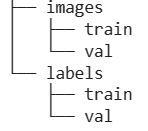


**- RAVINDER'S CLEANING AND FORMATTING OF IMAGES**, USE THIS ON FINAL DATASET

In [ ]:
import os
import shutil
import random

base_dir = 'drive/Dog Breeds Clean'
train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'

breeds = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]

for b in breeds:
    os.makedirs(os.path.join(train_dir, b), exist_ok=True)
    os.makedirs(os.path.join(val_dir, b), exist_ok=True)
    os.makedirs(os.path.join(test_dir, b), exist_ok=True)

    b_path = os.path.join(base_dir, b)
    imgs = [img for img in os.listdir(b_path) if os.path.isfile(os.path.join(b_path, img))]
    random.seed(42)
    random.shuffle(imgs)

    train_idx = int(len(imgs) * 0.7)
    val_idx = int(len(imgs) * 0.85)

    train_imgs = imgs[:train_idx]
    val_imgs = imgs[train_idx:val_idx]
    test_imgs = imgs[val_idx:]

    for img in train_imgs:
        shutil.copy(os.path.join(b_path, img), os.path.join(train_dir, b, img))
    for img in val_imgs:
        shutil.copy(os.path.join(b_path, img), os.path.join(val_dir, b, img))
    for img in test_imgs:
        shutil.copy(os.path.join(b_path, img), os.path.join(test_dir, b, img))

print("Done")

Done


In [ ]:
import os
import shutil
import random

if os.path.exists('dataset'):
    shutil.rmtree('dataset')

valid_exts = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

breeds = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f)) and not f.startswith('.') and f != '__MACOSX' and f != 'annotations']

for b in breeds:
    b_path = os.path.join(base_dir, b)
    imgs = [img for img in os.listdir(b_path) if os.path.isfile(os.path.join(b_path, img)) and img.lower().endswith(valid_exts)]

    if len(imgs) == 0:
        continue

    os.makedirs(os.path.join(train_dir, b), exist_ok=True)
    os.makedirs(os.path.join(val_dir, b), exist_ok=True)
    os.makedirs(os.path.join(test_dir, b), exist_ok=True)

    random.seed(42)
    random.shuffle(imgs)

    train_idx = int(len(imgs) * 0.7)
    val_idx = int(len(imgs) * 0.85)

    for img in imgs[:train_idx]:
        shutil.copy(os.path.join(b_path, img), os.path.join(train_dir, b, img))
    for img in imgs[train_idx:val_idx]:
        shutil.copy(os.path.join(b_path, img), os.path.join(val_dir, b, img))
    for img in imgs[val_idx:]:
        shutil.copy(os.path.join(b_path, img), os.path.join(test_dir, b, img))

print("Done cleaning and splitting.")

Done cleaning and splitting.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

t_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

t_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

d_train = datasets.ImageFolder(train_dir, transform=t_train)
d_val = datasets.ImageFolder(val_dir, transform=t_val_test)
d_test = datasets.ImageFolder(test_dir, transform=t_val_test)

dl_train = DataLoader(d_train, batch_size=32, shuffle=True)
dl_val = DataLoader(d_val, batch_size=32, shuffle=False)
dl_test = DataLoader(d_test, batch_size=32, shuffle=False)

print("Resizing Images.")
print(len(d_train), len(d_val), len(d_test))

Resizing Images.
2432 532 532


**END OF CLEANING AND FORMATTING -**

# Custom classification using YOLO

First install and import

In [9]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.14.6 torch-2.12.1 CPU (Apple M5)
Setup complete ✅ (10 CPUs, 16.0 GB RAM, 190.1/460.4 GB disk)


In [10]:
from ultralytics import YOLO

## Training YOLO

**IMPORT PRETRAINED CLASSIFICATION MODEL**

In [11]:
model = YOLO('yolov8s-cls.pt') # pretrained model

You shouldn't need to run this config creator below, leaving this here just in case we need it


In [ ]:
%%writefile config.yaml
path:
train: dataset/train
test: dataset/test
val: dataset/val

# Classes
nc: 19 # replace based on your dataset's number of classes

# Class names
# replace all class names with your own classes' names
names:
  0: beagle
  1: berneseMountiain
  2: borderCollie
  3: chihuahua
  4: chow
  5: cockerSpaniel
  6: corgi
  7: frenchBulldog
  8: germanShepherd
  9: goldenRetriever
  10: husky
  11: labrador
  12: maltese
  13: pomeranian
  14: poodle
  15: pyrenees
  16: scottishTerrier
  17: shihtzu
  18: yorkshireTerrier

Overwriting config.yaml


Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

**MAIN THING: TRAIN OUR YOLO MODEL HERE!**
TRY DIFFERENT PARAMETERS

mainly learning rate/lr0/lrf, cls, try others that are relevant and take note of what you used

Use link above for reference!!

In [14]:
model.train(
    data="final_dataset",
    epochs=15,
    patience=5,
    batch=8,
    lr0=0.0005,
    erasing=0.5,
    auto_augment="randaugment",
    cos_lr=True,
    project="dataset"
)

Ultralytics 8.4.90 🚀 Python-3.14.6 torch-2.12.1 CPU (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=final_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.5, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, p

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x127069220>
curves: []
curves_results: []
fitness: 0.9788011908531189
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9619883298873901, 'metrics/accuracy_top5': 0.9956140518188477, 'fitness': 0.9788011908531189}
save_dir: PosixPath('/Users/katesimone/Documents/test_python/runs/classify/dataset/train-3')
speed: {'preprocess': 0.0008858377127554159, 'inference': 24.247744882973564, 'loss': 5.215338338711109e-05, 'postprocess': 0.00012366821763394346}
top1: 0.9619883298873901
top5: 0.9956140518188477

path          final_dataset/val/frenchBulldog/frenchBulldog_...
true                                              frenchBulldog
pred                                              frenchBulldog
confidence                                                  1.0
correct                                                    True
Name: 447, dtype: object
path          final_dataset/val/poodle/2.jpeg
true                                   poodle
pred                                  maltese
confidence                           0.977849
correct                                 False
Name: 637, dtype: object


<Figure size 1000x500 with 2 Axes>

Working well: final_dataset/val/frenchBulldog/frenchBulldog_149.jpg
  True: frenchBulldog | Pred: frenchBulldog | Confidence: 1.00


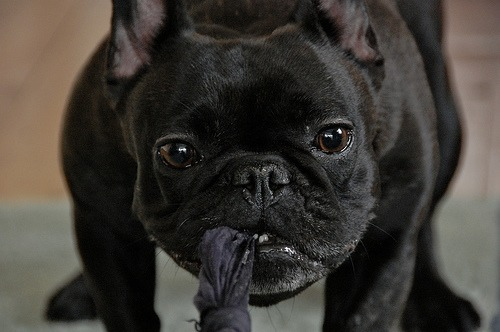


Failing: final_dataset/val/poodle/2.jpeg
  True: poodle | Pred: maltese | Confidence: 0.98


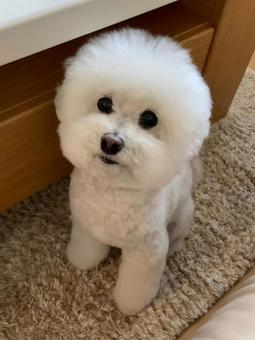

In [21]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd

model = YOLO('runs/classify/dataset/train-3/weights/best.pt')  # your trained weights

val_dir = Path('final_dataset/val')
records = []

for class_dir in val_dir.iterdir():
    if not class_dir.is_dir():
        continue
    true_label = class_dir.name
    for img_path in class_dir.glob('*.*'):
        result = model.predict(source=str(img_path), verbose=False)[0]
        pred_idx = result.probs.top1
        records.append({
            'path': str(img_path),
            'true': true_label,
            'pred': result.names[pred_idx],
            'confidence': result.probs.top1conf.item(),
            'correct': result.names[pred_idx] == true_label
        })

df = pd.DataFrame(records)
best_example = df[df.correct].sort_values('confidence', ascending=False).iloc[0]
worst_example = df[~df.correct].sort_values('confidence', ascending=False).iloc[0]

print(best_example)
print(worst_example)
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, row, title in zip(axes, [best_example, worst_example], ['Working well', 'Failing']):
    ax.imshow(Image.open(row['path']))
    ax.set_title(f"{title}\nTrue: {row['true']} | Pred: {row['pred']} ({row['confidence']:.2f})")
    ax.axis('off')
plt.tight_layout()
plt.show()
from IPython.display import display, Image as IPImage

print(f"Working well: {best_example['path']}")
print(f"  True: {best_example['true']} | Pred: {best_example['pred']} | Confidence: {best_example['confidence']:.2f}")
display(IPImage(filename=best_example['path'], width=400))

print(f"\nFailing: {worst_example['path']}")
print(f"  True: {worst_example['true']} | Pred: {worst_example['pred']} | Confidence: {worst_example['confidence']:.2f}")
display(IPImage(filename=worst_example['path'], width=400))

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [18]:
metrics = model.val(project="runs/classify/dataset/train-3")  # no other arguments needed, dataset and settings remembered
metrics.box.map    # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps   # a list contains map50-95 of each category
metrics.box.mp    # P
metrics.box.mr    # R

Ultralytics 8.4.90 🚀 Python-3.14.6 torch-2.12.1 CPU (Apple M5)
YOLOv8s-cls summary (fused): 30 layers, 5,099,539 parameters, 0 gradients, 12.5 GFLOPs
train: /Users/katesimone/Documents/test_python/final_dataset/train... found 2432 images in 19 classes ✅ 
val: /Users/katesimone/Documents/test_python/final_dataset/val... found 684 images in 19 classes ✅ 
test: /Users/katesimone/Documents/test_python/final_dataset/test... found 532 images in 19 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1020.7±1203.3 MB/s, size: 803.6 KB)
val: Scanning /Users/katesimone/Documents/test_python/final_dataset/val... 684 images, 0 corrupt: 100% ━━━━━━━━━━━━ 684/684 2.7Mit/s 0.0s
               classes   top1_acc   top5_acc: 25% ━━━───────── 11/43 1.0it/s 7.5s<31.7s


KeyboardInterrupt: 

Showing confusion matrix, that is already stored in detect/train folder

##Prediction

In [ ]:
model = YOLO("runs/classify/dataset/train-3/weights/best.pt")  # load a custom model

# Predict with the model
results = model("https://cdn.britannica.com/84/232784-050-1769B477/Siberian-Husky-dog.jpg")  # predict on an image

# Access the results
for result in results:
    if result.probs is not None:
        top1 = result.probs.top1  # top predicted class ID
        top1_conf = result.probs.top1conf  # top prediction confidence
        top1_name = result.names[top1]  # top predicted class name
        print(f"Top predicted class: {top1_name} with confidence: {top1_conf:.2f}")
    else:
        print("No classification probabilities available (likely no objects detected).")


image 1/1 C:\Users\eshan\OneDrive\Desktop\content\Siberian-Husky-dog.jpg: 224x224 husky 0.30, germanShepherd 0.09, chihuahua 0.08, corgi 0.07, pomeranian 0.06, 28.1ms
Speed: 14.3ms preprocess, 28.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Top predicted class: husky with confidence: 0.30


VALIDATION OF MODEL (AFTER 3 EPOCHS)

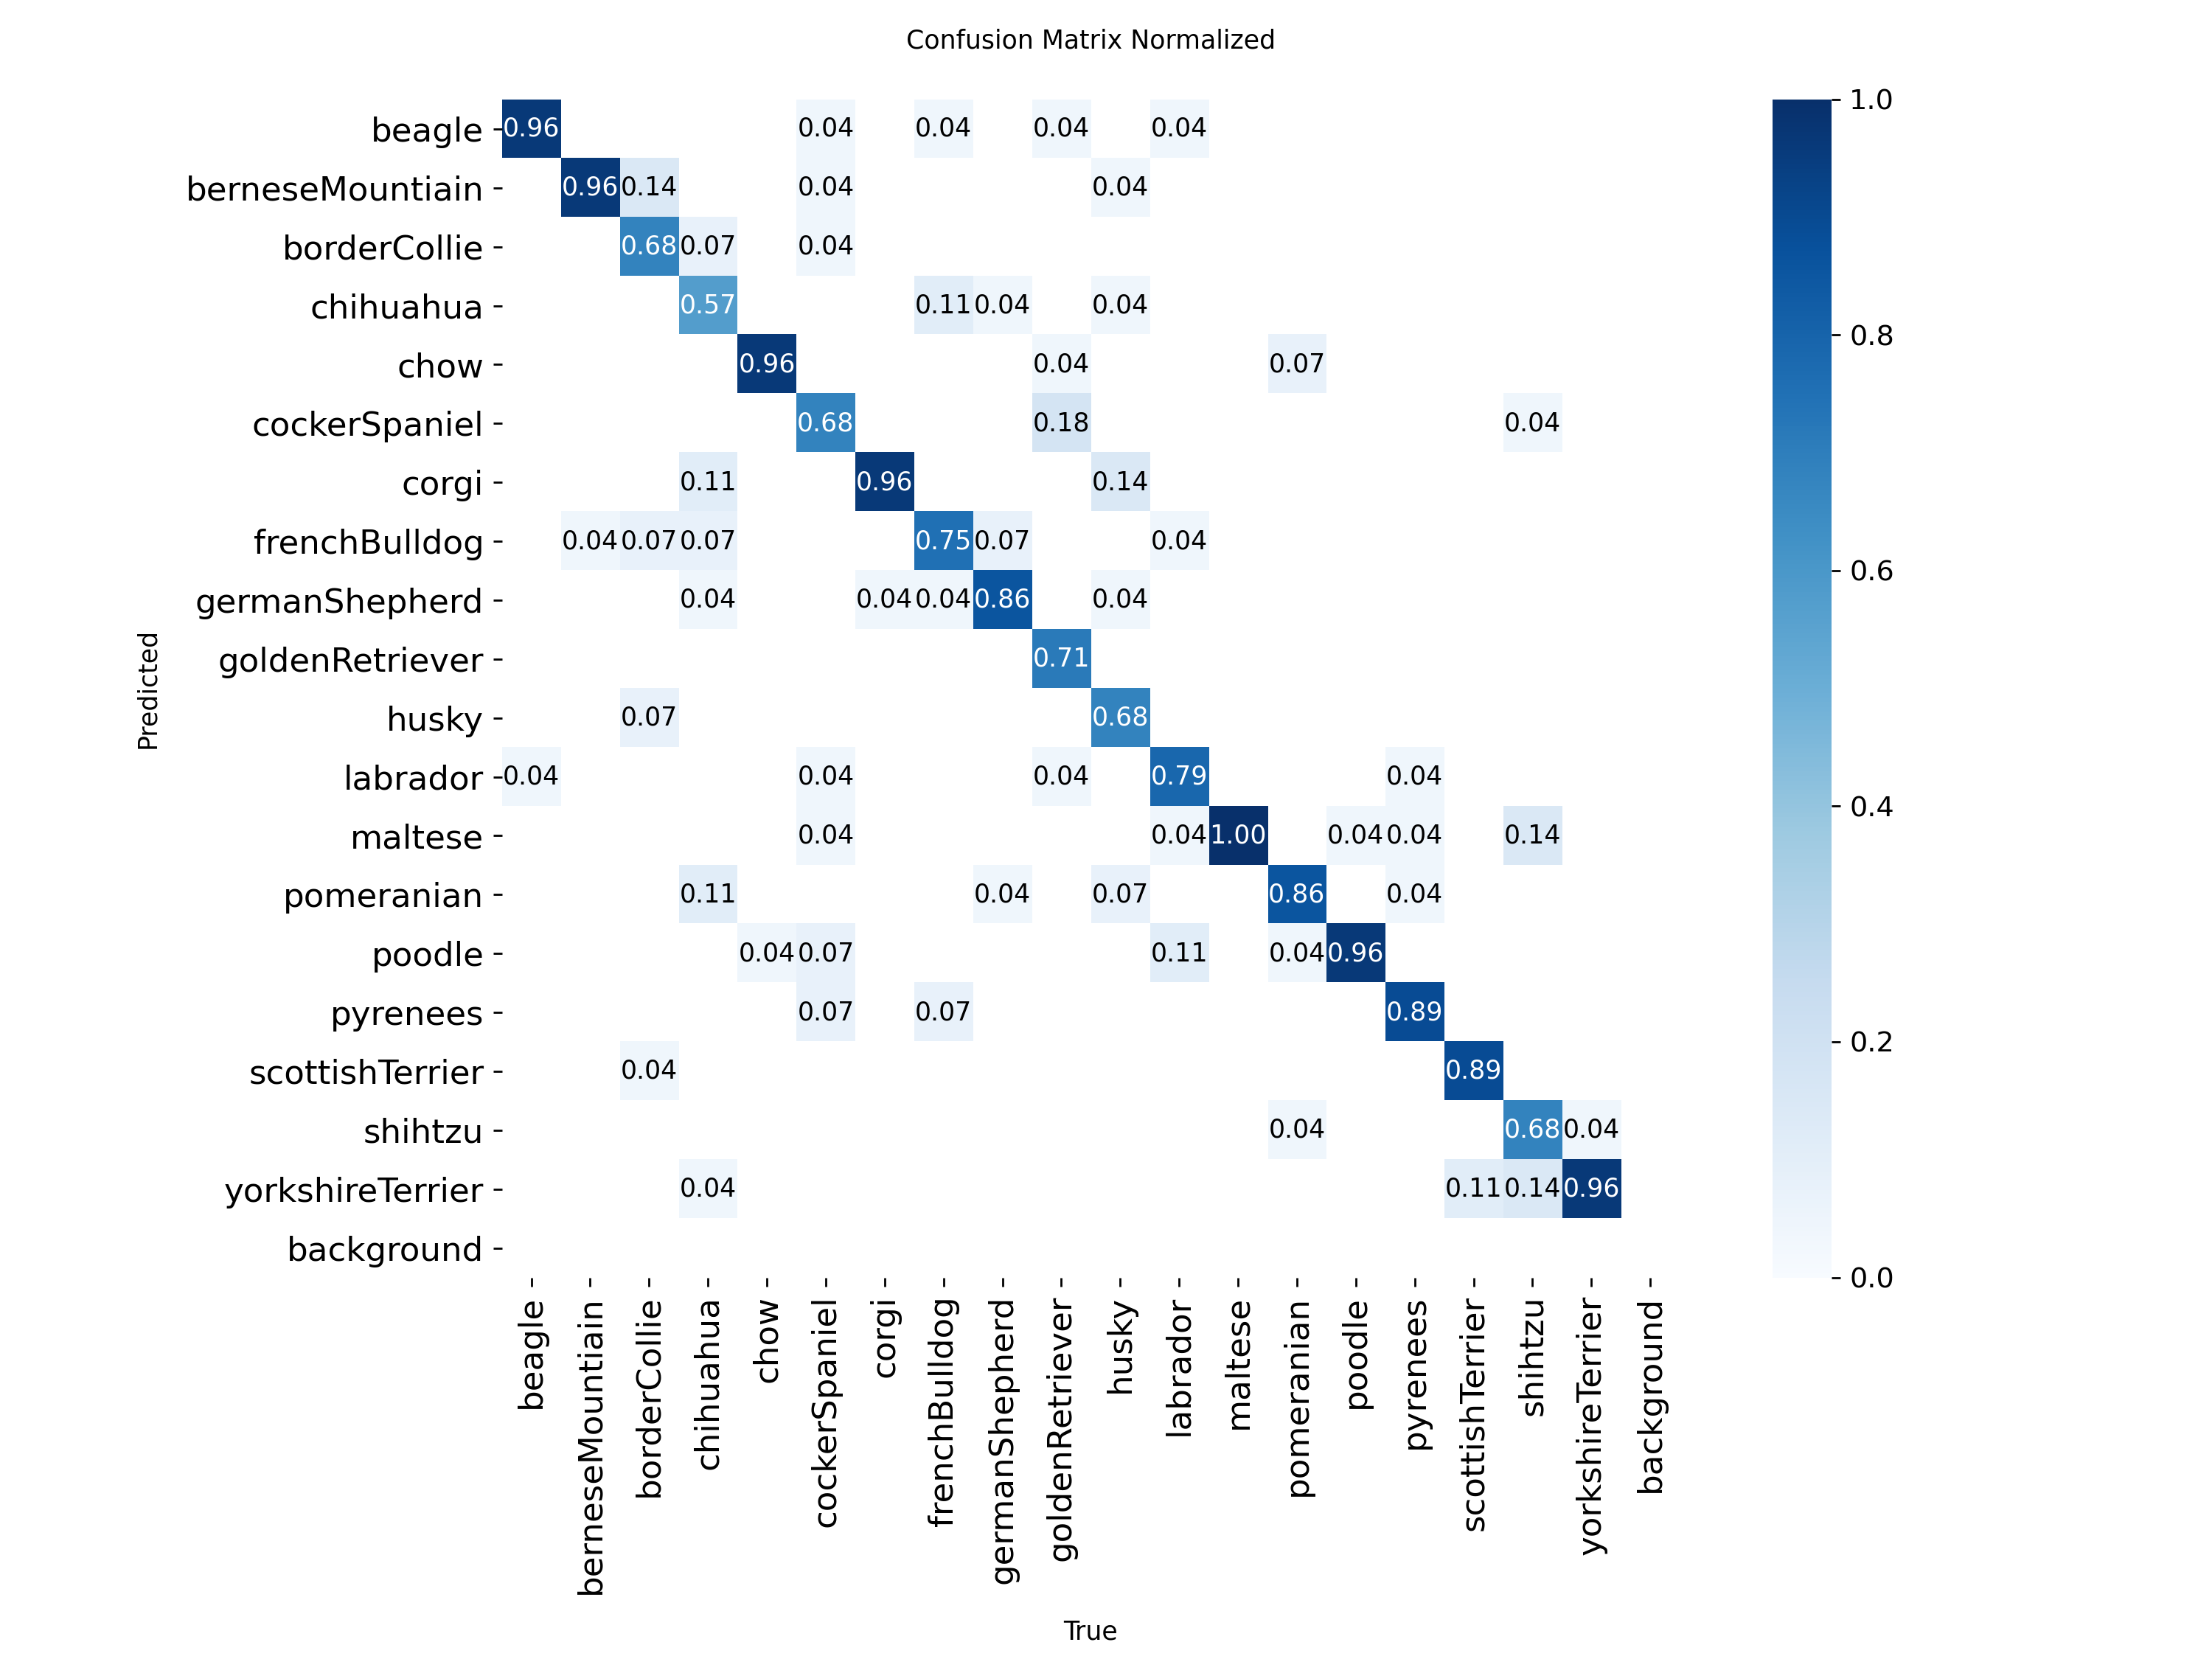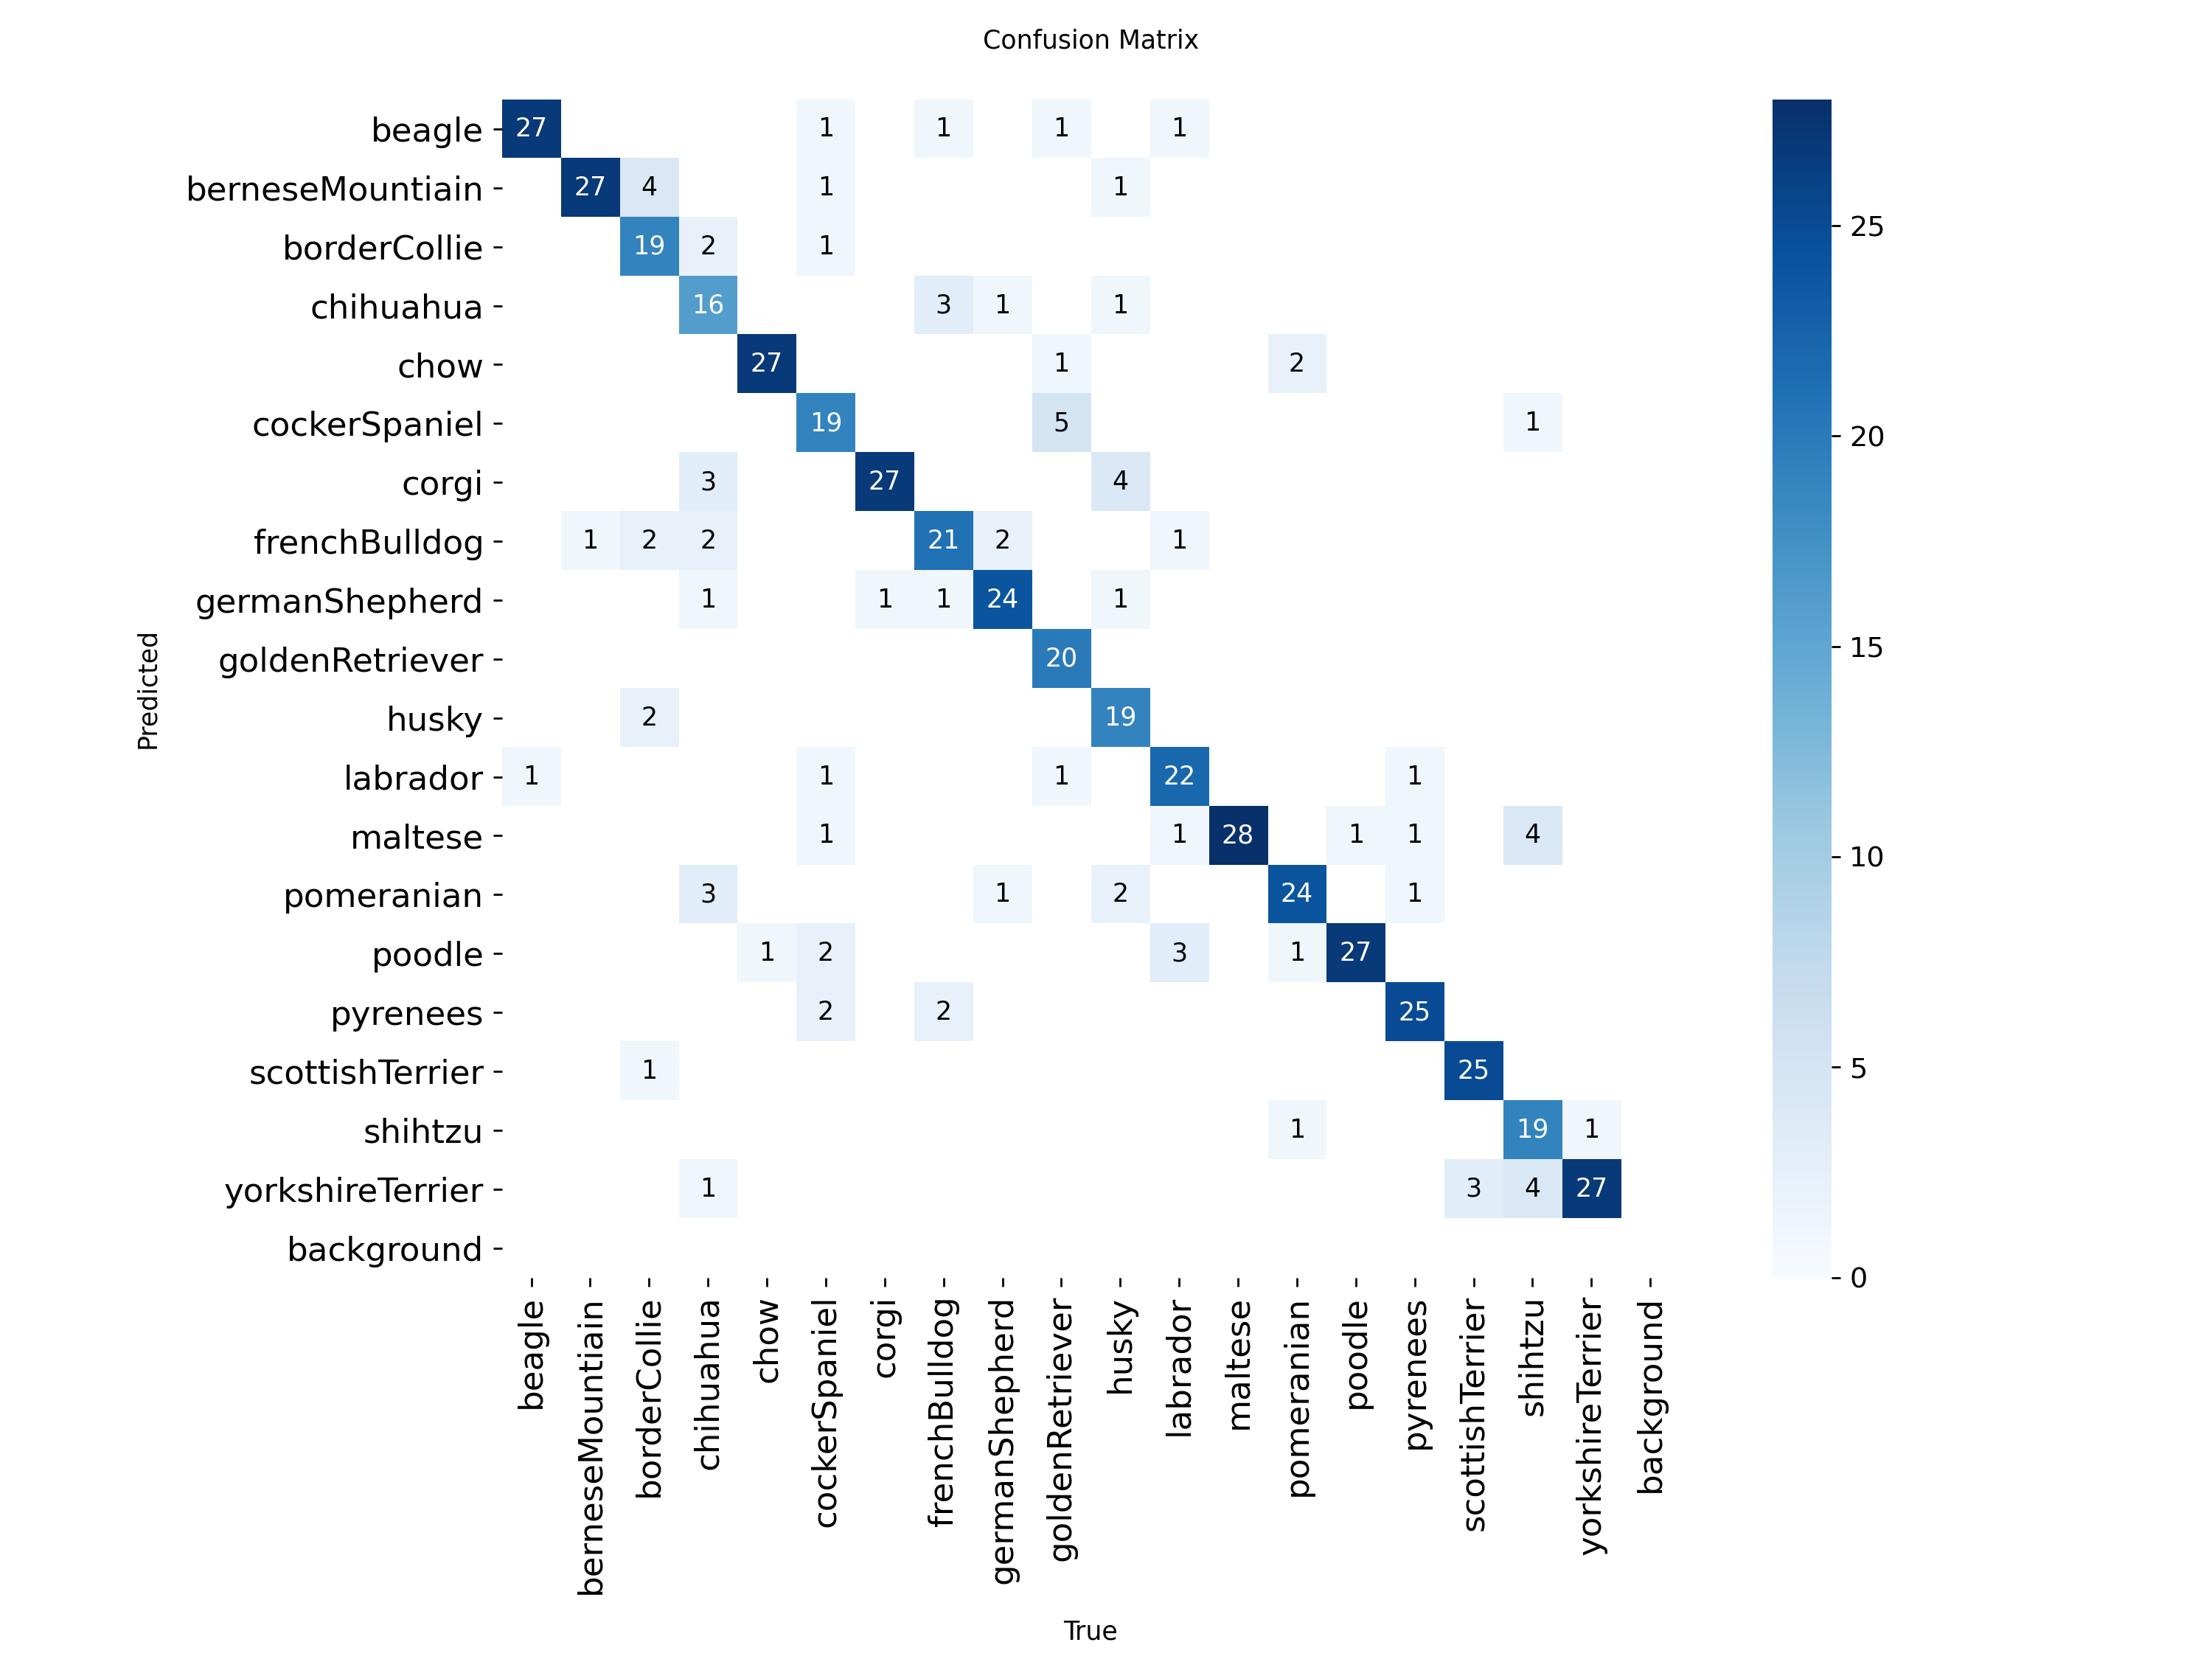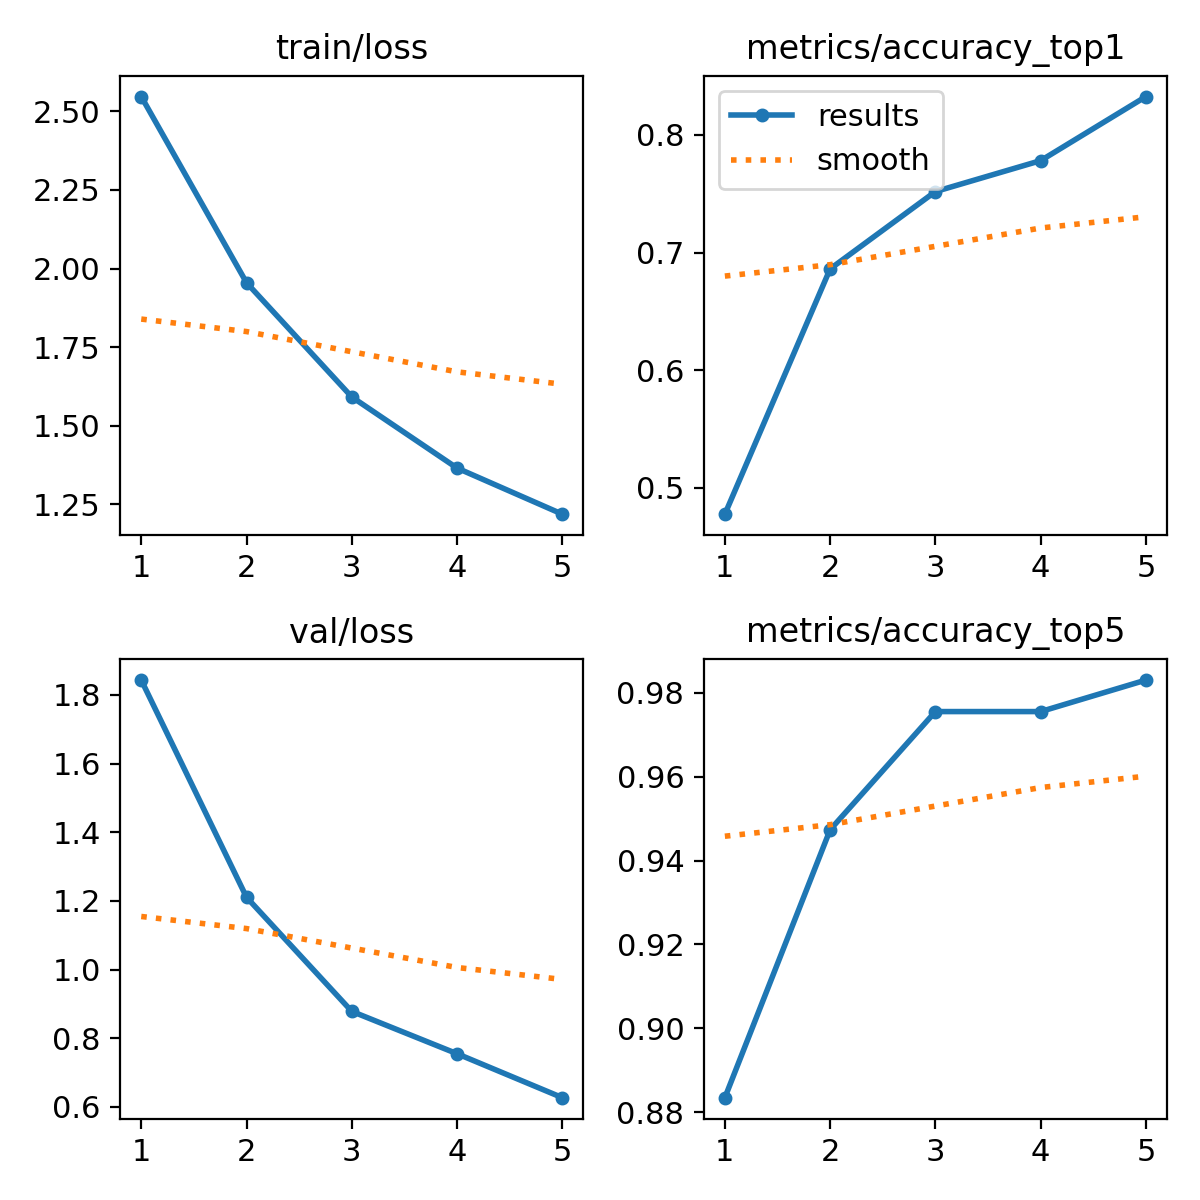